# Notebook 01: Dataset Validation

> **Tutorial question:** Before comparing outcomes, how do we know that the experiment itself is trustworthy?

This notebook is the quality-control stage of the project. We load the Hillstrom three-arm randomized experiment, inspect its schema, check business-logic constraints, verify the observed allocation against the planned 1:1:1 split, and test whether pre-experiment customer characteristics are balanced.

### What you will learn
- Why duplicate rows are not automatically data errors when no customer ID is available.
- How a Sample Ratio Mismatch (SRM) chi-square test checks randomization.
- How standardized mean differences (SMD) diagnose covariate imbalance.
- Why zero-inflated, right-skewed revenue needs special care later.

### Expected takeaway
If allocation is plausible, pre-treatment covariates are balanced, and the logical checks pass, later treatment comparisons can be interpreted under the randomized-experiment design.

## 1. Load the experiment data

The dataset contains one row per customer. `segment` is the treatment assignment; `visit`, `conversion`, and `spend` are measured after the email campaign. The code downloads the file only when it is missing, so rerunning the notebook is safe.

In [51]:
import warnings
from pathlib import Path
import urllib.request

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chisquare
from scipy.stats import ttest_ind

In [52]:
data_path = Path("../data/raw/hillstrom.csv")

if not data_path.exists():
    url = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
    data_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, data_path)
    print("Downloaded.")
else:
    print(f"Data already exists ({data_path.stat().st_size / 1024:.0f} KB).")

Data already exists (3872 KB).


In [53]:
hillstrom_df = pd.read_csv(data_path)

display(hillstrom_df.head(), hillstrom_df.tail())

display(hillstrom_df.describe())

display(hillstrom_df.info())

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0
63999,1,4) $350 - $500,472.82,0,1,Surburban,0,Web,Mens E-Mail,0,0,0.0


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


None

In [54]:
#print(f"Duplicate rows: {hillstrom_df.duplicated().sum()}")
print(f"Duplicate rows idx: {hillstrom_df.duplicated(keep=False)}")

Duplicate rows idx: 0        False
1        False
2        False
3        False
4        False
         ...  
63995    False
63996    False
63997     True
63998    False
63999    False
Length: 64000, dtype: bool


In [55]:
display(hillstrom_df[hillstrom_df.duplicated(keep=False)].sort_values(list(hillstrom_df.columns)).head(20))

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
18473,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,0,0,0.0
38460,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,0,0,0.0
42755,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,0,0,0.0
47127,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,0,0,0.0
51350,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,0,0,0.0
3748,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,1,0,0.0
30423,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,1,0,0.0
50187,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Mens E-Mail,1,0,0.0
13562,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Womens E-Mail,0,0,0.0
21256,1,1) $0 - $100,29.99,0,1,Rural,0,Phone,Womens E-Mail,0,0,0.0


#### Duplicate handling
 - Rows with identical covariate values across all columns  - likely customers with shared purchase profiles. Retained for analysis


In [56]:
# TODO: Register `hillstrom_df` as a DuckDB relation named `hillstrom`.
# Then write two SQL queries:
#   1. verify the total number of rows;
#   2. preview a small number of records.
# The required object is a DuckDB connection stored in `con`.
con = duckdb.connect()
con.execute(''' 
        CREATE TABLE hillstrom as
        SELECT * 
        FROM hillstrom_df''')
con.execute('''
        SELECT COUNT(*) as n_rows
        FROM hillstrom''').df()


,n_rows
0,64000


### Logical consistency checks
- Every conversion should have a visit (conversion=1 implies visit=1)
- Every non-zero spend should have a conversion (spend > 0 implies conversion=1)

In [57]:
# TODO: Write a SQL query that counts logical violations:
#   - conversion = 1 while visit = 0;
#   - spend > 0 while conversion = 0.
# Return one row with columns named `conversion_without_visit` and
# `spend_without_conversion`.
con.execute('''
        SELECT
            SUM(CASE WHEN conversion = 1 AND visit = 0 THEN 1 ELSE 0 END) as conversion_without_visit,
            SUM(CASE WHEN spend > 0 AND conversion = 0 THEN 1 ELSE 0 END) as spend_without_conversion
            FROM hillstrom
        ''').df()


,conversion_without_visit,spend_without_conversion
0,0.0,0.0


## 2. Exploration

### SRM: did random assignment create the expected group sizes?

The null hypothesis is that the three arms follow the planned 1:1:1 allocation. A large p-value does not prove perfect randomization; it means the observed deviations are compatible with chance.

In [58]:
# Obtain arm counts with SQL and test the observed counts against an equal
# 1:1:1 allocation using the Pearson chi-square SRM test.
srm_counts = con.execute('''
    SELECT segment, COUNT(*) AS observed_count
    FROM hillstrom
    GROUP BY segment
    ORDER BY segment
''').df()

observed_counts = srm_counts["observed_count"].to_numpy()
expected_count = observed_counts.sum() / len(observed_counts)
expected_counts = np.repeat(expected_count, len(observed_counts))
srm_statistic, srm_pvalue = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts,
)
srm_alpha = 0.05
srm_detected = srm_pvalue < srm_alpha

srm_counts["expected_count"] = expected_counts
srm_counts["residual_pct"] = (
    (srm_counts["observed_count"] - srm_counts["expected_count"])
    / srm_counts["expected_count"]
    * 100
)

print("Observed arm counts:")
display(srm_counts.round({"expected_count": 2, "residual_pct": 3}))
print(f"SRM chi-square statistic = {srm_statistic:.4f}")
print(f"SRM p-value = {srm_pvalue:.4f}")
print(f"Conclusion at alpha={srm_alpha:.2f}: " + (
    "reject equal allocation" if srm_detected
    else "do not reject equal allocation"
))

Observed arm counts:


,segment,observed_count,expected_count,residual_pct
0,Mens E-Mail,21307,21333.33,-0.123
1,No E-Mail,21306,21333.33,-0.128
2,Womens E-Mail,21387,21333.33,0.252


SRM chi-square statistic = 0.2025
SRM p-value = 0.9037
Conclusion at alpha=0.05: do not reject equal allocation


### Baseline rates (visit rate, conversion rate, mean spend) per arm


In [59]:
# TODO: Write a SQL query that returns, by segment:
#   segment, sample size, visit rate, conversion rate, and mean spend.
# Group and order the result by `segment`.
df_metrics = con.execute('''
        SELECT segment, count(*) as sample_size, avg(visit) as visit_rate, avg(conversion) as conversion_rate, avg(spend) as mean_spend
        FROM hillstrom
        GROUP BY segment
        ORDER BY segment
        ''').df()
df_metrics


,segment,sample_size,visit_rate,conversion_rate,mean_spend
0,Mens E-Mail,21307,0.182757,0.012531,1.422617
1,No E-Mail,21306,0.106167,0.005726,0.652789
2,Womens E-Mail,21387,0.151400,0.008837,1.077202


### Check covariate balance

Randomization should make customer characteristics similar before treatment. We inspect numeric summaries and categorical proportions, then use SMD as a scale-free diagnostic. As a rule of thumb, absolute SMD below 0.1 indicates good balance.

In [60]:
# TODO: Write a SQL query that returns, by segment, the means of the
# pre-treatment variables `recency`, `history`, `newbie`, `mens`, and `womens`.
# Round the continuous and proportion columns for presentation.
df_pre_treatment = con.execute('''
        SELECT segment, avg(recency) as mean_recency, avg(history) as mean_history, avg(newbie) as mean_newbie, avg(mens) as mean_mens, avg(womens) as mean_womens
        FROM hillstrom
        GROUP BY segment
        ORDER BY segment
        ''').df()
df_pre_treatment


,segment,mean_recency,mean_history,mean_newbie,mean_mens,mean_womens
0,Mens E-Mail,5.773642,242.835931,0.501525,0.550946,0.551415
1,No E-Mail,5.749695,240.882653,0.501971,0.553224,0.547639
2,Womens E-Mail,5.767850,242.536633,0.503250,0.548932,0.550101


In [ ]:
# TODO: Write a SQL query for the distribution of `channel` within each
# segment. Return counts and within-segment percentages using a window function.
df_channel_distribution = con.execute(''' 
    SELECT segment, channel, count(*)/sum(count(*)) OVER (PARTITION BY segment) as count
    FROM hillstrom
    GROUP BY segment, channel
    ORDER BY segment, channel
''').df()
df_channel_distribution


,segment,channel,count
0,Mens E-Mail,Multichannel,0.120946
1,Mens E-Mail,Phone,0.433660
2,Mens E-Mail,Web,0.445394
3,No E-Mail,Multichannel,0.122313
4,No E-Mail,Phone,0.437764
5,No E-Mail,Web,0.439923
6,Womens E-Mail,Multichannel,0.120587
7,Womens E-Mail,Phone,0.442044
8,Womens E-Mail,Web,0.437368


In [62]:
# TODO: Write a SQL query for the distribution of `zip_code` within each
# segment. Return counts and within-segment percentages using a window function.
df_zip_code_distribution = con.execute('''
    SELECT segment, zip_code, count(*)/sum(count(*)) OVER (PARTITION BY segment) as count
    FROM hillstrom
    GROUP BY segment, zip_code
    ORDER BY segment, zip_code
''').df()
df_zip_code_distribution


,segment,zip_code,count
0,Mens E-Mail,Rural,0.152204
1,Mens E-Mail,Surburban,0.445910
2,Mens E-Mail,Urban,0.401887
3,No E-Mail,Rural,0.147329
4,No E-Mail,Surburban,0.451751
5,No E-Mail,Urban,0.400920
6,Womens E-Mail,Rural,0.148735
7,Womens E-Mail,Surburban,0.451209
8,Womens E-Mail,Urban,0.400056


In [63]:
# TODO: Complete the SMD function and apply it to each pre-treatment
# covariate, comparing each email arm with No E-Mail.
# Use |SMD| < 0.1 as the balance diagnostic threshold.
def smd(group1, group2):
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1), np.std(group2)
    std = np.sqrt((std1 ** 2 + std2 ** 2) / 2)
    return abs(mean1 - mean2) / std if std != 0 else 0

pre_treatment_covariates = ["recency", "history", "newbie", "mens", "womens"]
control_mask = hillstrom_df["segment"] == "No E-Mail"
smd_rows = []

for email_arm in ["Mens E-Mail", "Womens E-Mail"]:
    treatment_mask = hillstrom_df["segment"] == email_arm
    for covariate in pre_treatment_covariates:
        smd_value = smd(
            hillstrom_df.loc[treatment_mask, covariate],
            hillstrom_df.loc[control_mask, covariate],
        )
        smd_rows.append({
            "comparison": f"{email_arm} vs No E-Mail",
            "covariate": covariate,
            "smd": smd_value,
            "balanced": smd_value < 0.1,
        })

smd_results = pd.DataFrame(smd_rows)
display(smd_results.round({"smd": 4}))

,comparison,covariate,smd,balanced
0,Mens E-Mail vs No E-Mail,recency,0.0068,True
1,Mens E-Mail vs No E-Mail,history,0.0076,True
2,Mens E-Mail vs No E-Mail,newbie,0.0009,True
3,Mens E-Mail vs No E-Mail,mens,0.0046,True
4,Mens E-Mail vs No E-Mail,womens,0.0076,True
5,Womens E-Mail vs No E-Mail,recency,0.0052,True
6,Womens E-Mail vs No E-Mail,history,0.0065,True
7,Womens E-Mail vs No E-Mail,newbie,0.0026,True
8,Womens E-Mail vs No E-Mail,mens,0.0086,True
9,Womens E-Mail vs No E-Mail,womens,0.0049,True


### Inspect the outcome distribution

Revenue is not a normal-looking continuous variable here: most customers spend nothing and a small number spend a lot. That affects standard errors, visualization, power, and later sensitivity analyses.

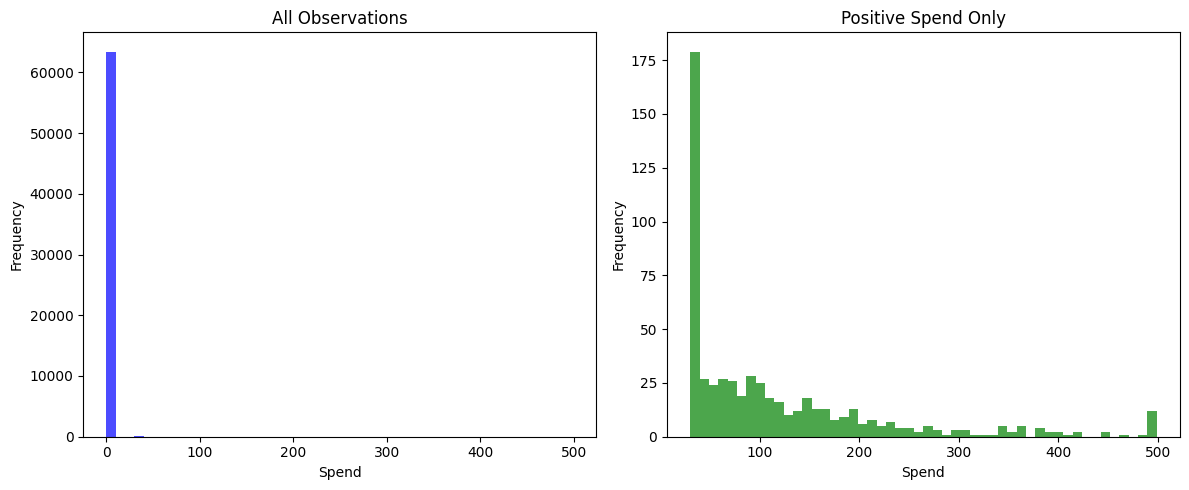

In [66]:
# TODO: Write a SQL query that summarizes `spend` with:
# percentage equal to zero, mean, median, standard deviation, and maximum.
# Then create two histograms: all observations and positive spend only.
con.execute('''
    SELECT
        SUM(CASE WHEN spend = 0 THEN 1 ELSE 0 END) / COUNT(*) AS pct_equal_zero,
        AVG(spend) AS mean_spend,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY spend) AS median_spend,
        STDDEV(spend) AS stddev_spend,
        MAX(spend) AS max_spend
    FROM hillstrom
''').df()
all = hillstrom_df["spend"].values
positive_spend = hillstrom_df[hillstrom_df["spend"] > 0]["spend"].values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(all, bins=50, color="blue", alpha=0.7)
plt.title("All Observations")
plt.xlabel("Spend")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.hist(positive_spend, bins=50, color="green", alpha=0.7)
plt.title("Positive Spend Only")
plt.xlabel("Spend")
plt.ylabel("Frequency")
plt.tight_layout()

## Summary
- No SRM found (p-value = 0.90), arm sizes are as expected
- Covariates are balanced and randomization held (SMD < 0.1)
- The men's email had the highest rate of visits, conversions, and spending
- Spend is heavily zero inflated (the code output is about 99.1% zeroes) with a long right tail
- No nulls, no logical violations.
- **Data is verified and ready for hypothesis testing**